In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yassinedridi20/creditdataset/loan_dataset_20000 (1).csv


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# Modèles à tester
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import joblib
import shap

In [4]:
df = pd.read_csv("/kaggle/input/datasets/yassinedridi20/creditdataset/loan_dataset_20000 (1).csv")
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [6]:
target = "loan_paid_back"

categorical_cols = [
    "gender", "marital_status", "education_level",
    "employment_status", "loan_purpose", "grade_subgrade"
]

numerical_cols = [
    "age", "annual_income", "monthly_income",
    "debt_to_income_ratio", "credit_score",
    "num_of_open_accounts", "total_credit_limit",
    "current_balance", "loan_amount",
    "interest_rate", "loan_term",
    "installment", "num_of_delinquencies"
]
numerical_cols.remove("credit_score")

In [7]:
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num", numeric_transformer, numerical_cols)
    ])

In [9]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

params = {
    "LogisticRegression": {
        "model__C": [0.1, 1, 10]
    },
    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20]
    },
    "GradientBoosting": {
        "model__learning_rate": [0.01, 0.1],
        "model__n_estimators": [100, 200]
    },
    "SVM": {
        "model__C": [0.1, 1],
        "model__gamma": ["scale", "auto"]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1]
    }
}

In [10]:
X = df[categorical_cols + numerical_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
results = []

for model_name in models:
    model = models[model_name]
    
    clf = Pipeline(steps=[("preprocessor", preprocessor),
                         ("model", model)])
    
    grid = GridSearchCV(
        estimator=clf,
        param_grid=params[model_name],
        cv=3,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    print(f"\n➡️ Training {model_name} ...")
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "model": model_name,
        "best_params": grid.best_params_,
        "accuracy": acc,
        "roc_auc": auc,
        "f1_score": f1
    })
    
    print(f"✔️ {model_name} done")


➡️ Training LogisticRegression ...
✔️ LogisticRegression done

➡️ Training RandomForest ...
✔️ RandomForest done

➡️ Training GradientBoosting ...
✔️ GradientBoosting done

➡️ Training SVM ...
✔️ SVM done

➡️ Training XGBoost ...
✔️ XGBoost done


In [12]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="accuracy", ascending=False)

,model,best_params,accuracy,roc_auc,f1_score
4,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.89425,0.883264,0.937025
2,GradientBoosting,"{'model__learning_rate': 0.1, 'model__n_estima...",0.89350,0.881155,0.936475
1,RandomForest,"{'model__max_depth': 10, 'model__n_estimators'...",0.89250,0.866784,0.936107
0,LogisticRegression,{'model__C': 1},0.88750,0.883175,0.932249
3,SVM,"{'model__C': 1, 'model__gamma': 'auto'}",0.87675,0.854721,0.925675


In [13]:
best_row = results_df.sort_values(by="accuracy", ascending=False).iloc[0]
best_model_name = best_row["model"]

print("Best model:", best_model_name)

# Refit and save
best_model = models[best_model_name]
best_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", best_model)])
best_pipeline.fit(X, y)

joblib.dump(best_pipeline, "best_loan_model.pkl")
print("Best model saved as best_loan_model.pkl")

Best model: XGBoost
Best model saved as best_loan_model.pkl


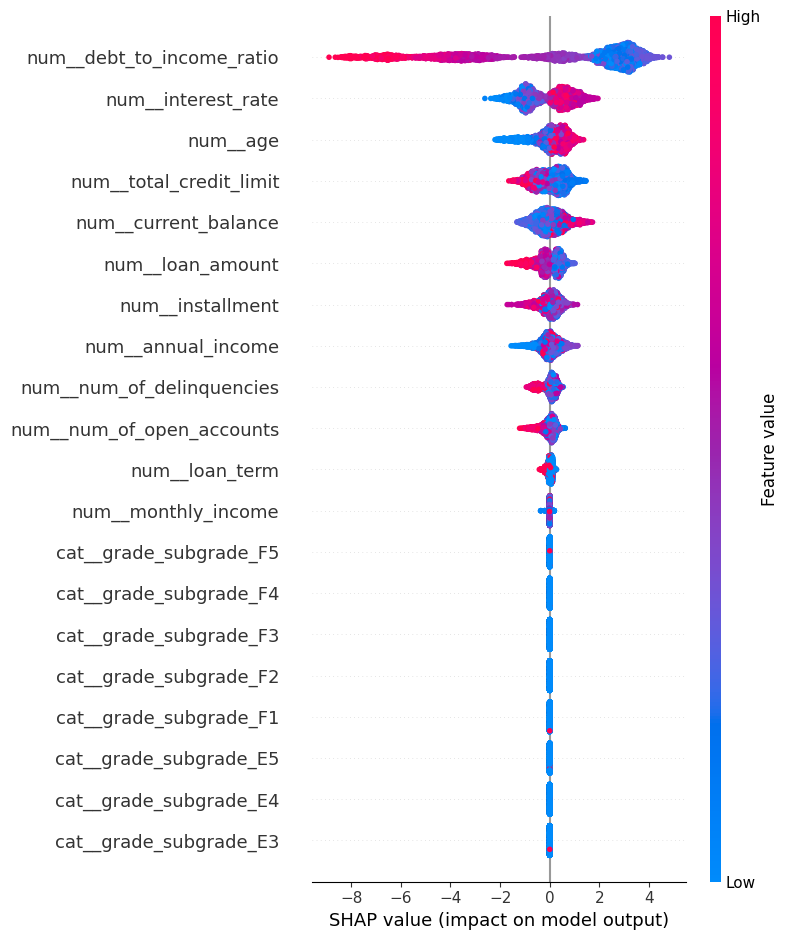

In [17]:
# Transformer X_test en dense numpy array via le pipeline complet
X_test_transformed = best_pipeline.named_steps["preprocessor"].transform(X_test)

# Si c'est sparse -> dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# SHAP Explainer
import shap
explainer = shap.TreeExplainer(best_pipeline.named_steps["model"], X_test_transformed)
shap_values = explainer(X_test_transformed)

# Affichage summary plot
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)




def predict_risk(input_data):
    proba = model.predict_proba(input_data)[0][1]
    
    if proba < 0.2:
        risk = "LOW"
    elif proba < 0.5:
        risk = "MEDIUM"
    else:
        risk = "HIGH"
    
    return {
        "default_probability": float(proba),
        "risk_level": risk
    }

In [33]:
import numpy as np
import shap

def predict_risk(input_data_df):
    """
    Prédit le risque de défaut pour un client et identifie les features qui ont le plus d'impact.

    Arguments :
    - input_data_df : pd.DataFrame contenant les nouvelles données client.

    Retour :
    - dict avec :
        * default_probability : probabilité de défaut (float)
        * risk_level : LOW / MEDIUM / HIGH
        * top_features : liste des 5 features les plus impactantes avec impact moyen
    """
    # Transformer les nouvelles données avec le pipeline
    input_transformed = best_pipeline.named_steps["preprocessor"].transform(input_data_df)
    
    # Si sparse -> dense
    if hasattr(input_transformed, "toarray"):
        input_transformed = input_transformed.toarray()
    
    # Prédiction proba et classe
    proba_default = best_pipeline.named_steps["model"].predict_proba(input_transformed)[0][0]  # défaut = 0
    predicted_class = best_pipeline.named_steps["model"].predict(input_transformed)[0]
    
    # Définir le niveau de risque
    if proba_default < 0.2:
        risk = "LOW"
    elif proba_default < 0.5:
        risk = "MEDIUM"
    else:
        risk = "HIGH"
    
    # SHAP explainer pour expliquer la prédiction
    explainer = shap.TreeExplainer(best_pipeline.named_steps["model"])
    shap_values = explainer.shap_values(input_transformed)
    
    # Récupérer les noms des features après preprocessing
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    
    # Calculer l'impact moyen absolu de chaque feature
    shap_values_mean = np.abs(shap_values).mean(axis=0)
    
    # Top 5 features
    top_idx = np.argsort(shap_values_mean)[-5:]
    top_features = [(feature_names[i], float(shap_values_mean[i])) for i in reversed(top_idx)]
    
    return {
        "default_probability": float(proba_default),
        "risk_level": risk,
        "top_features": top_features
    }

In [29]:
import pandas as pd

# Exemple de données client
client_data = {
    "age": [23],
    "annual_income": [14939.69],
    "monthly_income": [1244.974],
    "debt_to_income_ratio": [0.032],
    "credit_score": [743],
    "num_of_open_accounts": [7],
    "total_credit_limit": [40833.47],
    "current_balance": [24302.07],
    "loan_amount": [50000],
    "interest_rate": [11.99],
    "loan_term": [36],
    "installment": [197.99],
    "num_of_delinquencies": [1],
    "gender": ["Male"],
    "marital_status": ["Married"],
    "education_level": ["Bachelor"],
    "employment_status": ["Employed"],
    "loan_purpose": ["Home improvement"],
    "grade_subgrade": ["B5"]
}

client_df = pd.DataFrame(client_data)

In [34]:
risk_result = predict_risk(client_df)
print(risk_result)

{'default_probability': 0.0007128119468688965, 'risk_level': 'LOW', 'top_features': [('num__debt_to_income_ratio', 4.134923458099365), ('cat__employment_status_Unemployed', 1.778140902519226), ('cat__grade_subgrade_A3', 1.6770700216293335), ('cat__employment_status_Retired', 1.373964548110962), ('cat__grade_subgrade_A2', 1.3627625703811646)]}


In [32]:
import joblib
joblib.dump(explainer, "shap_explainer.pkl")

['shap_explainer.pkl']